# Sentiment Analysis

In this assignment we use IMDb movie reviews for binary sentiment classification. The goal is to predict whether a review is positive or negative. Because the input is text, we first convert reviews into numerical Bag-of-Words features and then train a neural network using TensorFlow/Keras, following the course materials.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from numpy.random import seed
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, SGD

## Load Data

The labels are strings in the original files, so we convert them to binary values: `1` for positive reviews and `0` for negative reviews.

In [2]:
reviews = pd.read_csv("reviews.txt", header=None, names=["review"])
labels = pd.read_csv("labels.txt", header=None, names=["label"])

reviews["sentiment"] = (labels["label"] == "positive").astype(int)

print(reviews.shape)
reviews.head()

(25000, 2)


,review,sentiment
0,bromwell high is a cartoon comedy . it ran at ...,1
1,story of a man who has unnatural feelings for ...,0
2,homelessness or houselessness as george carli...,1
3,airport starts as a brand new luxury pla...,0
4,brilliant over acting by lesley ann warren . ...,1


## Initial Data Check

Before modelling, we check the class balance and look at a few examples. This is a supervised binary classification problem.

Class counts:
sentiment
0    12500
1    12500
Name: count, dtype: int64

Class proportions:
sentiment
0    0.5
1    0.5
Name: proportion, dtype: float64


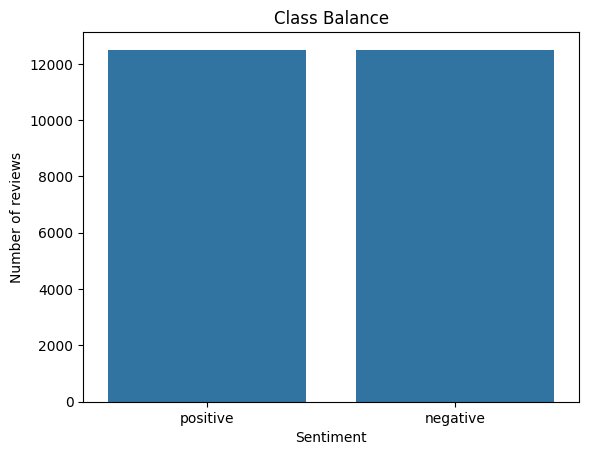

In [3]:
print("Class counts:")
print(reviews["sentiment"].value_counts().sort_index())
print()
print("Class proportions:")
print(reviews["sentiment"].value_counts(normalize=True).sort_index())

label_names = {0: "negative", 1: "positive"}
reviews["sentiment_name"] = reviews["sentiment"].map(label_names)

sns.countplot(data=reviews, x="sentiment_name")
plt.title("Class Balance")
plt.xlabel("Sentiment")
plt.ylabel("Number of reviews")
plt.show()

In [4]:
for sentiment_value, sentiment_name in label_names.items():
    example = reviews.loc[reviews["sentiment"] == sentiment_value, "review"].iloc[0]
    print(f"Example {sentiment_name} review:")
    print(example[:600])
    print()
    print("-" * 80)
    print()


Example negative review:
story of a man who has unnatural feelings for a pig . starts out with a opening scene that is a terrific example of absurd comedy . a formal orchestra audience is turned into an insane  violent mob by the crazy chantings of it  s singers . unfortunately it stays absurd the whole time with no general narrative eventually making it just too off putting . even those from the era should be turned off . the cryptic dialogue would make shakespeare seem easy to a third grader . on a technical level it  s better than you might think with some good cinematography by future great vilmos zsigmond . futur

--------------------------------------------------------------------------------

Example positive review:
bromwell high is a cartoon comedy . it ran at the same time as some other programs about school life  such as  teachers  . my   years in the teaching profession lead me to believe that bromwell high  s satire is much closer to reality than is  teachers  . the scramb

## Train / Validation / Test Split

We split the raw text before fitting the vectorizer. Training data is used to fit the model, validation data is used for model selection, and test data is kept untouched until the final evaluation. Stratification keeps the positive/negative balance stable across splits.

In [5]:
X_text = reviews["review"]
y = reviews["sentiment"]

X_train_val_text, X_test_text, y_train_val, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_val_text,
    y_train_val,
    test_size=0.2,
    random_state=0,
    stratify=y_train_val
)

print(f"Train size: {len(X_train_text)}")
print(f"Validation size: {len(X_val_text)}")
print(f"Test size: {len(X_test_text)}")
print()
print("Train class balance:")
print(y_train.value_counts(normalize=True).sort_index())
print("Validation class balance:")
print(y_val.value_counts(normalize=True).sort_index())
print("Test class balance:")
print(y_test.value_counts(normalize=True).sort_index())

Train size: 16000
Validation size: 4000
Test size: 5000

Train class balance:
sentiment
0    0.5
1    0.5
Name: proportion, dtype: float64
Validation class balance:
sentiment
0    0.5
1    0.5
Name: proportion, dtype: float64
Test class balance:
sentiment
0    0.5
1    0.5
Name: proportion, dtype: float64


## Bag-of-Words Representation

`CountVectorizer` converts text into word-count vectors. We fit it only on the training text and only transform validation/test text. This avoids data leakage, because the vocabulary is learned without looking at validation or test data.

In [6]:
vectorizer = CountVectorizer(max_features=10000)

X_train_sparse = vectorizer.fit_transform(X_train_text)
X_val_sparse = vectorizer.transform(X_val_text)
X_test_sparse = vectorizer.transform(X_test_text)

feature_names = vectorizer.get_feature_names_out()

print(f"Train shape: {X_train_sparse.shape}")
print(f"Validation shape: {X_val_sparse.shape}")
print(f"Test shape: {X_test_sparse.shape}")
print(f"Vocabulary size: {len(feature_names)}")

Train shape: (16000, 10000)
Validation shape: (4000, 10000)
Test shape: (5000, 10000)
Vocabulary size: 10000


## Explore The Representation

A single word is represented by one column index in the vocabulary. A whole review becomes a 10,000-dimensional sparse vector of word counts.

In [7]:
word = "movie"
word_index = vectorizer.vocabulary_[word]

print(f"The word '{word}' is represented by feature index {word_index}.")
print(f"Count of '{word}' in the first training review: {int(X_train_sparse[0, word_index])}")

first_review_vector = X_train_sparse[0]
nonzero_indices = first_review_vector.nonzero()[1]
top_terms = sorted(
    [(feature_names[idx], int(first_review_vector[0, idx])) for idx in nonzero_indices],
    key=lambda item: (-item[1], item[0])
)[:15]

print(f"A whole review is a sparse 10,000-dimensional vector with {first_review_vector.nnz} non-zero entries.")
print("Top non-zero word counts in the first training review:")
print(top_terms)
print()
print("First training review snippet:")
print(X_train_text.iloc[0][:400])

The word 'movie' is represented by feature index 5846.
Count of 'movie' in the first training review: 5
A whole review is a sparse 10,000-dimensional vector with 252 non-zero entries.
Top non-zero word counts in the first training review:
[('the', 34), ('of', 16), ('to', 16), ('and', 15), ('br', 14), ('that', 10), ('in', 9), ('you', 9), ('it', 8), ('this', 8), ('be', 6), ('on', 6), ('people', 6), ('with', 6), ('all', 5)]

First training review snippet:
okay  now  i know there are millions of americans who believe in the rapture that moment when all people born again in christ will be raptured up to meet god and all the rest of humanity will be left on earth to perish in plagues and fire and the heartbreak of psoriasis as the antichrist battles it out with jesus  in an uncharacteristically warlike mode  . and i know the books were best sellers . 


## Prepare Data For Keras

The Bag-of-Words matrices are sparse. For this simple feed-forward Keras model, we convert them to dense `float32` arrays. The trade-off is higher memory usage, but the code stays close to the neural-network examples from the course.

In [8]:
X_train = X_train_sparse.astype("float32").toarray()
X_val = X_val_sparse.astype("float32").toarray()
X_test = X_test_sparse.astype("float32").toarray()

y_train_array = y_train.to_numpy().astype("float32")
y_val_array = y_val.to_numpy().astype("float32")
y_test_array = y_test.to_numpy().astype("float32")

input_size = X_train.shape[1]

print(f"Input size: {input_size}")
print(f"X_train dtype: {X_train.dtype}")
print(f"y_train dtype: {y_train_array.dtype}")

Input size: 10000
X_train dtype: float32
y_train dtype: float32


## Baseline Neural Network

This is a feed-forward neural network with one hidden layer. The output layer has one neuron with sigmoid activation because this is binary classification.

In [9]:
seed(0)
tf.random.set_seed(0)

baseline_model = Sequential()
baseline_model.add(Input(shape=(input_size,)))
baseline_model.add(Dense(units=32, activation="relu"))
baseline_model.add(Dense(units=1, activation="sigmoid"))

baseline_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │       320,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,065 (1.22 MB)

 Trainable params: 320,065 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
baseline_history = baseline_model.fit(
    X_train,
    y_train_array,
    epochs=8,
    batch_size=64,
    validation_data=(X_val, y_val_array),
    verbose=1
)

Epoch 1/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6808 - loss: 0.6104 - val_accuracy: 0.7340 - val_loss: 0.5554
Epoch 2/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7703 - loss: 0.5156 - val_accuracy: 0.7793 - val_loss: 0.4912
Epoch 3/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8016 - loss: 0.4649 - val_accuracy: 0.8035 - val_loss: 0.4555
Epoch 4/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8192 - loss: 0.4336 - val_accuracy: 0.8217 - val_loss: 0.4254
Epoch 5/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8328 - loss: 0.4104 - val_accuracy: 0.8338 - val_loss: 0.4052
Epoch 6/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8434 - loss: 0.3916 - val_accuracy: 0.8430 - val_loss: 0.3908
Epoch 7/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8500 - loss: 0.3759 - val_accuracy: 0.8447 - val_loss: 0.3829
Epoch 8/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8566 - loss: 0.3618 - val_accuracy: 0.8485 - v

## Learning Curves

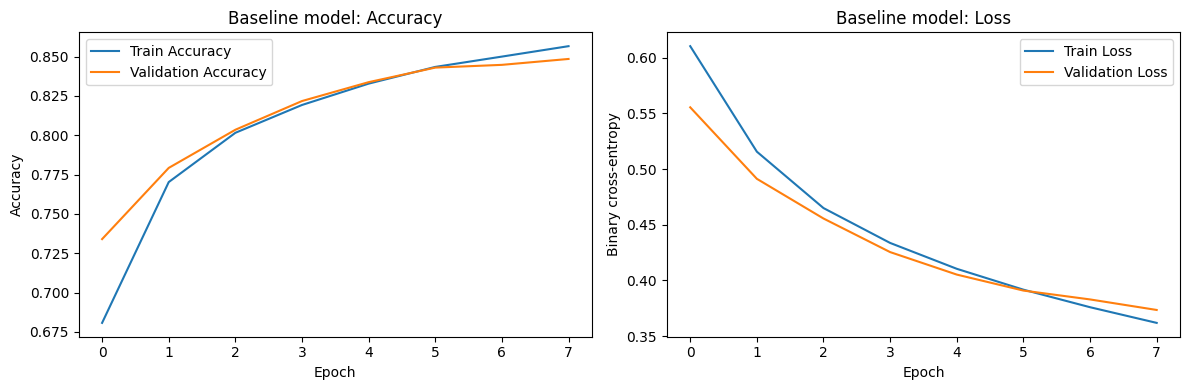

In [11]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Baseline model")

In [12]:
train_loss, train_accuracy = baseline_model.evaluate(X_train, y_train_array, verbose=0)
val_loss, val_accuracy = baseline_model.evaluate(X_val, y_val_array, verbose=0)

print(f"Baseline train accuracy: {train_accuracy:.4f}")
print(f"Baseline validation accuracy: {val_accuracy:.4f}")
print(f"Baseline train loss: {train_loss:.4f}")
print(f"Baseline validation loss: {val_loss:.4f}")

Baseline train accuracy: 0.8645
Baseline validation accuracy: 0.8485
Baseline train loss: 0.3426
Baseline validation loss: 0.3734


## Hyperparameter Tuning

We tune only a few relevant hyperparameters: number of hidden units, activation function, L2 regularization, and optimizer. The test set is not used here.

In [13]:
def build_model(hidden_units, activation, l2_strength, optimizer_name):
    model = Sequential()
    model.add(Input(shape=(input_size,)))
    model.add(Dense(
        units=hidden_units,
        activation=activation,
        kernel_regularizer=regularizers.l2(l2_strength) if l2_strength > 0 else None
    ))
    model.add(Dense(units=1, activation="sigmoid"))

    if optimizer_name == "adam":
        optimizer = Adam(learning_rate=0.001)
    else:
        optimizer = SGD(learning_rate=0.01)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

candidate_settings = [
    {"hidden_units": 32, "activation": "relu", "l2_strength": 0.0, "optimizer_name": "adam"},
    {"hidden_units": 64, "activation": "relu", "l2_strength": 0.001, "optimizer_name": "adam"},
    {"hidden_units": 64, "activation": "tanh", "l2_strength": 0.001, "optimizer_name": "adam"},
]

results = []
trained_models = []

for i, settings in enumerate(candidate_settings):
    seed(i)
    tf.random.set_seed(i)

    model = build_model(**settings)
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train_array,
        epochs=10,
        batch_size=64,
        validation_data=(X_val, y_val_array),
        callbacks=[early_stopping],
        verbose=0
    )

    train_loss, train_accuracy = model.evaluate(X_train, y_train_array, verbose=0)
    val_loss, val_accuracy = model.evaluate(X_val, y_val_array, verbose=0)

    result = settings.copy()
    result["train_accuracy"] = round(train_accuracy, 4)
    result["val_accuracy"] = round(val_accuracy, 4)
    result["train_loss"] = round(train_loss, 4)
    result["val_loss"] = round(val_loss, 4)
    result["epochs"] = len(history.history["loss"])
    results.append(result)
    trained_models.append((model, history, settings, val_accuracy))

results_df = pd.DataFrame(results).sort_values("val_accuracy", ascending=False).reset_index(drop=True)
results_df

,hidden_units,activation,l2_strength,optimizer_name,train_accuracy,val_accuracy,train_loss,val_loss,epochs
0,32,relu,0.000,adam,0.9405,0.8907,0.1920,0.2834,3
1,64,relu,0.001,adam,0.9204,0.8805,0.3058,0.3914,3
2,64,tanh,0.001,adam,0.9252,0.8733,0.2828,0.3737,3


Best validation accuracy: 0.8907
Best settings: {'hidden_units': 32, 'activation': 'relu', 'l2_strength': 0.0, 'optimizer_name': 'adam'}


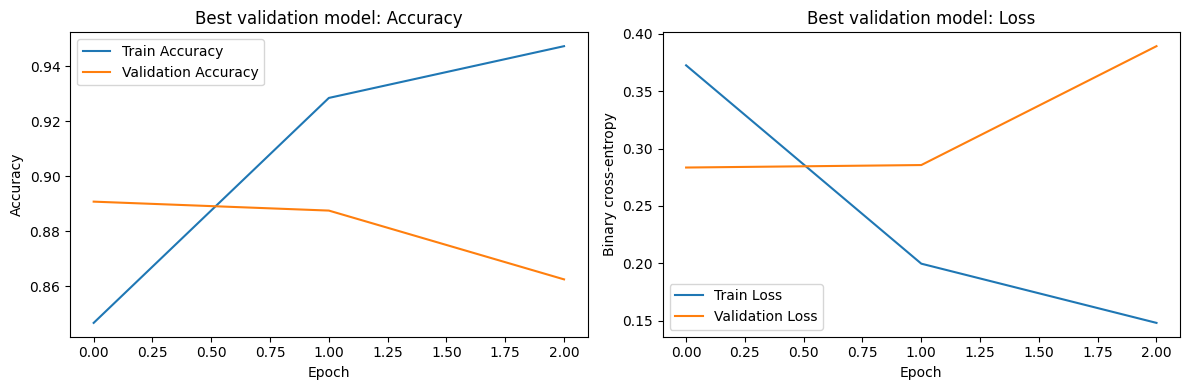

In [14]:
best_model, best_history, best_settings, best_val_accuracy = max(
    trained_models,
    key=lambda item: item[3]
)

print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best settings: {best_settings}")

plot_history(best_history, "Best validation model")

## Final Model And Test Evaluation

After choosing hyperparameters using the validation set, we refit the vectorizer on train + validation text and train the final model on train + validation data. The test set is evaluated only once at the end.

In [15]:
vectorizer_final = CountVectorizer(max_features=10000)

X_train_val_sparse = vectorizer_final.fit_transform(X_train_val_text)
X_test_final_sparse = vectorizer_final.transform(X_test_text)

X_train_val = X_train_val_sparse.astype("float32").toarray()
X_test_final = X_test_final_sparse.astype("float32").toarray()

y_train_val_array = y_train_val.to_numpy().astype("float32")
y_test_final_array = y_test.to_numpy().astype("float32")

final_input_size = X_train_val.shape[1]
print(f"Final train + validation shape: {X_train_val.shape}")
print(f"Final test shape: {X_test_final.shape}")

Final train + validation shape: (20000, 10000)
Final test shape: (5000, 10000)


In [16]:
def build_final_model(settings):
    model = Sequential()
    model.add(Input(shape=(final_input_size,)))
    model.add(Dense(
        units=settings["hidden_units"],
        activation=settings["activation"],
        kernel_regularizer=regularizers.l2(settings["l2_strength"]) if settings["l2_strength"] > 0 else None
    ))
    model.add(Dense(units=1, activation="sigmoid"))

    if settings["optimizer_name"] == "adam":
        optimizer = Adam(learning_rate=0.001)
    else:
        optimizer = SGD(learning_rate=0.01)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

seed(0)
tf.random.set_seed(0)

final_model = build_final_model(best_settings)
final_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │       320,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,065 (1.22 MB)

 Trainable params: 320,065 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
final_epochs = len(best_history.history["loss"])

final_history = final_model.fit(
    X_train_val,
    y_train_val_array,
    epochs=final_epochs,
    batch_size=64,
    verbose=1
)

print(f"Final model trained for {final_epochs} epochs.")


Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8574 - loss: 0.3531
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9306 - loss: 0.1931
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9510 - loss: 0.1409
Final model trained for 3 epochs.


In [18]:
test_loss, test_accuracy = final_model.evaluate(X_test_final, y_test_final_array, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

test_probabilities = final_model.predict(X_test_final).ravel()
test_predictions = (test_probabilities >= 0.5).astype(int)

print("Classification report:")
print(classification_report(y_test, test_predictions, target_names=["negative", "positive"]))

Test loss: 0.3518
Test accuracy: 0.8788
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification report:
              precision    recall  f1-score   support

    negative       0.86      0.91      0.88      2500
    positive       0.91      0.85      0.87      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



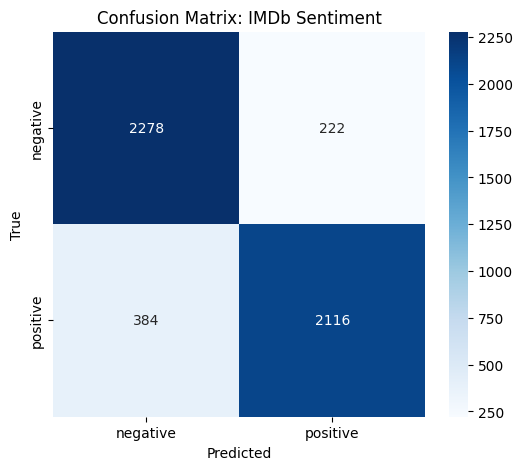

In [19]:
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: IMDb Sentiment")
plt.show()

## Classify Custom Sentences

For new sentences, we use the same final vectorizer. We do not fit a new vectorizer, because the model expects the same vocabulary columns as during training.

In [20]:
my_sentences = [
    "An excellent and touching movie with brilliant performances.",
    "This was a boring waste of time with terrible acting.",
    "The story was simple, but the film was warm and funny.",
    "I expected much more; the plot was weak and the ending was bad.",
    "Not perfect, but still an enjoyable and charming watch."
]

X_custom_sparse = vectorizer_final.transform(my_sentences)
X_custom = X_custom_sparse.astype("float32").toarray()

custom_probabilities = final_model.predict(X_custom).ravel()
custom_predictions = (custom_probabilities >= 0.5).astype(int)

for sentence, prediction, probability in zip(my_sentences, custom_predictions, custom_probabilities):
    predicted_label = "positive" if prediction == 1 else "negative"
    print(f"{predicted_label} (positive probability = {probability:.4f}) -> {sentence}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
positive (positive probability = 0.8548) -> An excellent and touching movie with brilliant performances.
negative (positive probability = 0.0628) -> This was a boring waste of time with terrible acting.
positive (positive probability = 0.7139) -> The story was simple, but the film was warm and funny.
negative (positive probability = 0.1915) -> I expected much more; the plot was weak and the ending was bad.
positive (positive probability = 0.7852) -> Not perfect, but still an enjoyable and charming watch.


## Limitations

Bag-of-Words is simple and useful, but it ignores word order and context. This means the model can struggle with negation, sarcasm, and phrases where meaning depends on word sequence. The dense conversion also uses more memory. More advanced text models could use TF-IDF, embeddings, recurrent models, or transformers, but this notebook stays close to the neural-network workflow from the course.